# Corollary 4 — Grassmannian Subspace Distance: Verification Walkthrough

A short, results-first tour of the numerical verification of **Corollary 4** of
*Multifactor Dispersion Bias with Per-Column Prevalence*.

Where Equation (6) Part (ii) tracks each factor's eigenvector error *separately*,
Corollary 4 zooms out to the **whole loading subspace at once**. It states that as
$p \to \infty$ (conditional on $F$, a.s.) the squared Grassmannian distance between
the sample loading subspace $\mathrm{col}(H)$ and the population subspace
$\mathrm{col}(\bar B)$ converges to the **sum of the per-factor floors**:

$$ d_{\mathrm{Gr}}^2\big(\mathrm{col}(H),\, \mathrm{col}(\bar B)\big)\ \longrightarrow\ \sum_{j} \frac{\delta^2}{n\rho_j + \delta^2}. $$

The in-subspace rotation cancels in the Grassmannian metric, so the subspace
distance is purely the sum of floors. This notebook builds the model **inline**
(parameters specified here, not loaded from JSON) and runs the
`SubspaceDistanceExperiment` probe through the same engine as the Part (ii) check
— a different question, same `run_experiment`, no engine change.

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
logger.remove()  # keep the notebook quiet

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_corollary4 import SubspaceDistanceExperiment, print_summary

print("ready")

ready


## 1 — Configure the model inline

Rather than loading from `model_spec.json`, we write the factor model out
explicitly here. These are the canonical diagonal-Gram parameters in **volatility**
units (the engine squares them into variances when it builds the model):

- a **market-like factor 1** with loadings $\beta_1 \sim N(1, 1)$, plus two
  zero-mean factors $\beta_2, \beta_3 \sim N(0, 1)$ — so the off-diagonal Gram
  entries vanish and $G_\infty = I_k$ holds;
- factor vols $\sigma = [0.16,\, 0.08,\, 0.06]$ (variances $[0.0256,\, 0.0064,\, 0.0036]$);
- constant idiosyncratic vol $0.4$, so $\delta^2 = 0.16$.

The design is a small smoke sweep over $p$ at fixed $n=60$; swap in the commented
line for the fuller run.

In [2]:
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],                 # volatilities; squared into F
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 1.0},   # market-like factor
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},  # delta = 0.4 -> delta^2 = 0.16
)

design = DesignSpec(
    n_values=[60],
    p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40,
    random_seed=20260511,
)
# Fuller sweep: design = DesignSpec(n_values=[30, 60, 120], n_reps=300)

dvars = [round(v ** 2, 4) for v in model.factor_vols]
print(f"k={model.k_factors}, factor_vols={model.factor_vols} -> variances={dvars}")
print(f"idio_vol={model.idio_vol_sampler['value']} -> delta^2={model.idio_vol_sampler['value'] ** 2:.4f}")
print(f"n={design.n_values}, p={design.p_values}, reps={design.n_reps}")

k=3, factor_vols=[0.16, 0.08, 0.06] -> variances=[0.0256, 0.0064, 0.0036]
idio_vol=0.4 -> delta^2=0.1600
n=[60], p=[200, 500, 1000, 2000, 5000], reps=40


## 2 — Run the sweep

`run_experiment(model, design, probe)` builds a fresh model per $(n, p)$ cell,
simulates `n_reps` replications, and for each one runs the probe's two analyses:
the new `SubspaceDistanceAnalysis` (observed LHS) and the **reused**
`Eq6RHSAnalysis` (whose per-factor floors are summed for the prediction). The probe
emits **one scalar row per replication** — `(n, p, d_gr2_obs, d_gr2_pred, gap)` —
rather than the $k$ per-factor rows the Part (ii) probe produces.

In [3]:
df = run_experiment(model, design, SubspaceDistanceExperiment(), progress=False)
print("rows:", len(df), " columns:", list(df.columns))
df.head()

rows: 200  columns: ['n', 'p', 'd_gr2_obs', 'd_gr2_pred', 'gap']


,n,p,d_gr2_obs,d_gr2_pred,gap
0,60,200,1.047846,0.796256,0.251590
1,60,200,1.063585,0.884810,0.178775
2,60,200,0.958955,0.823742,0.135213
3,60,200,0.911633,0.822842,0.088791
4,60,200,1.148060,0.783734,0.364326


## 3 — The confirmation

The RMSE of the gap $\big(d_{\mathrm{Gr}}^2 - \sum_j \text{floor}_j\big)$ per
$(n, p)$ should **fall as $p$ grows** — that decline is the numerical confirmation
of Corollary 4.

In [4]:
print_summary(df)


RMSE of (d_Gr² − Σ floors)  [smaller is better; should → 0 as p grows]

p     200     500     1000    2000    5000
n                                         
60 0.23984 0.06382 0.03916 0.02436 0.01418



## 4 — Figures

Two custom views of the result. **Left:** mean observed vs. predicted subspace
distance across $p$ — the two curves should pull together as $p$ grows. **Right:**
the gap RMSE on a log-$p$ axis, trending toward zero.

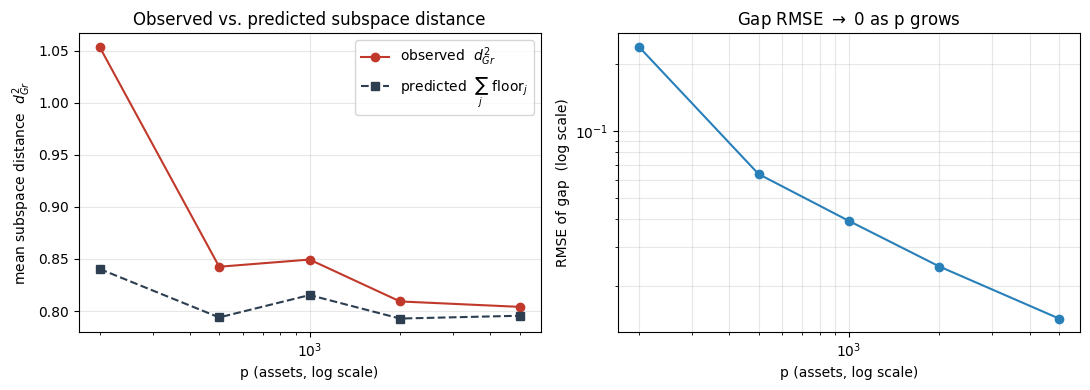

In [5]:
means = df.groupby("p")[["d_gr2_obs", "d_gr2_pred"]].mean()
rmse = (df.groupby("p")["gap"]
          .apply(lambda g: float(np.sqrt((g ** 2).mean()))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(means.index, means["d_gr2_obs"], "o-", label=r"observed  $d_{Gr}^2$", color="#c0392b")
ax1.plot(means.index, means["d_gr2_pred"], "s--", label=r"predicted  $\sum_j$ floor$_j$", color="#2c3e50")
ax1.set_xscale("log")
ax1.set_xlabel("p (assets, log scale)")
ax1.set_ylabel(r"mean subspace distance  $d_{Gr}^2$")
ax1.set_title("Observed vs. predicted subspace distance")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rmse.index, rmse.values, "o-", color="#2980b9")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("p (assets, log scale)")
ax2.set_ylabel(r"RMSE of gap  (log scale)")
ax2.set_title(r"Gap RMSE $\to$ 0 as p grows")
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## 5 — Cleaner convergence: nested sampling

Setting `sampling="nested"` draws one superset model + returns at $p_{\max}$ per
replicate and takes each smaller $p$ as its first-$p$ asset subset — so every $p$
sees the *same* assets and factor realization, removing cross-$p$ sampling noise.
The probe is unchanged; output rows simply carry a `rep` column. The result is a
cleaner monotone-in-$p$ curve.

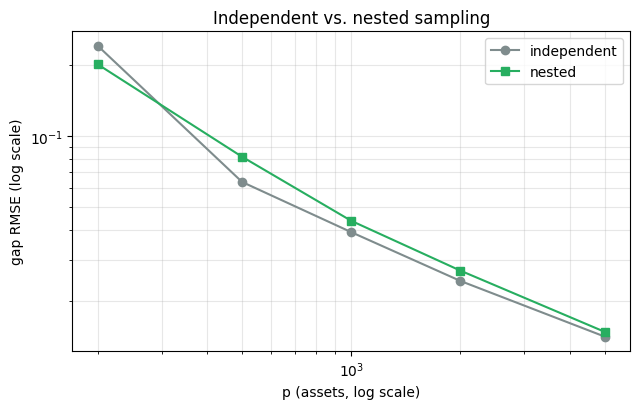

nested has a rep column: True


In [6]:
nested = DesignSpec(
    n_values=[60], p_values=[200, 500, 1000, 2000, 5000],
    n_reps=40, random_seed=20260511,
    sampling="nested",
)
df_nested = run_experiment(model, nested, SubspaceDistanceExperiment(), progress=False)

rmse_ind = df.groupby("p")["gap"].apply(lambda g: float(np.sqrt((g ** 2).mean())))
rmse_nst = df_nested.groupby("p")["gap"].apply(lambda g: float(np.sqrt((g ** 2).mean())))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(rmse_ind.index, rmse_ind.values, "o-", label="independent", color="#7f8c8d")
ax.plot(rmse_nst.index, rmse_nst.values, "s-", label="nested", color="#27ae60")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("p (assets, log scale)"); ax.set_ylabel("gap RMSE (log scale)")
ax.set_title("Independent vs. nested sampling")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("nested has a rep column:", "rep" in df_nested.columns)

## Notes

- The model was specified **inline** here — no `model_spec.json` needed. The same
  `ModelSpec` could equally be referenced from a design JSON; the runtime object is
  identical either way.
- Corollary 4 reuses `Eq6RHSAnalysis` from the Part (ii) probe verbatim — only the
  observed-LHS analysis (`SubspaceDistanceAnalysis`) and the per-replication record
  schema are new. That is the extension pattern: a new question is a new
  `Experiment`, the engine and seams are untouched.
- For a fuller run, widen the design (`n_values=[30, 60, 120]`, `n_reps=300`) or
  point it at a richer $p$ grid.